# D12:  Implementation of a new neural network training strategy based on a statistical method


<div style="text-align: center;">
    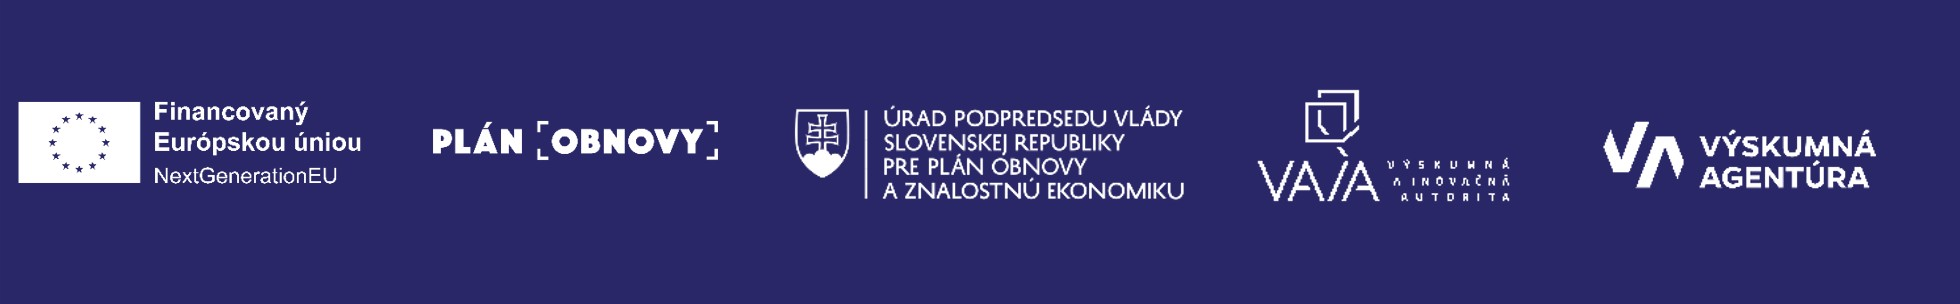
</div>


## Project identification

| | |
|---|---|
| **Project title** | A Statistical Approach to Monitor Quantisation in Neural Network Training |
| **Project acronym** | SAMQ-NN |
| **Project code** | 09I03-03-V04-00562 |
| **Programme** | Recovery and Resilience Plan of the Slovak Republic |
| **Component** | 9. More effective governance and strengthening of the funding of research, development and innovation under the Recovery and Resilience Plan of the Slovak Republic |
| **Investment** | 3. Excellent science |
| **Aid scheme** | State aid scheme to support research, development and innovation under Component 9 of the Recovery and Resilience Plan of the Slovak Republic, No. SA.106633 |
| **Project start** | 06/2024 |
| **End of implementation** | 05/2026 |
| **Principal investigator** | Ing. Roman Budjač, PhD. |

## 1. Introduction

Quantisation is among the most effective techniques for compressing neural networks: converting weights from a 32-bit floating-point representation (FP32) to lower bit precision (typically 8 or 4 bits) substantially reduces both the memory and computational demands of the model, yet inevitably changes its weight distribution and may lead to a loss of accuracy.

The analysis in deliverable **D10** demonstrated that comparing weight distributions can be integrated directly into the training of a quantised model with negligible overhead, and that the statistical index responds to the severity of quantisation. This deliverable **implements those findings into a functional training strategy**, while paying close attention to the **methodological soundness of the quantisation**.

A key difference from simplified implementations is that the strategy does not rely merely on simulating quantisation combined with full-precision training. Such an approach would let the weights drift off the quantisation grid back to arbitrary real values during training, so that the resulting model would not in fact be quantised. Instead, we implement **genuine quantisation-aware training (QAT)**, in which the forward pass uses quantised weights and the backward pass employs a straight-through estimator; the effective weights thus remain genuinely quantised throughout the entire process (which we also verify numerically in the notebook).

The notebook is organised as follows: the statistical core and a detailed description of the index (Chapter 2), characterisation and visual comparison of the weight distribution (Chapter 3), genuine quantisation, both post-training and QAT (Chapter 4), the training strategy itself (Chapter 5), the experimental proof of concept (Chapter 6), scaling to ImageNet (Chapter 7), and the conclusion (Chapter 8).

<div align="center">

### Deliverable D12 &nbsp;·&nbsp; Work Package WP3

# Implementation of a new neural network training strategy based on a statistical method

**Project:** A Statistical Approach to Monitor Quantisation in Neural Network Training (**SAMQ-NN**)
**Project code:** 09I03-03-V04-00562 &nbsp;·&nbsp; **Investment 3, Excellent Science, Recovery and Resilience Plan of the Slovak Republic**

**Prepared by:** Ing. Roman Budjač, PhD.

</div>

---

## Abstract

This deliverable implements a **new training strategy** for quantised neural networks, in which a statistical similarity index of the weight distribution is computed continuously during training and used to control the training process. Unlike a simple simulation of quantisation, the strategy uses **genuine quantisation-aware training** (QAT) with a straight-through estimator, so the effective weights of the model remain genuinely quantised on a grid with $2^b$ levels throughout the entire training. The index is evaluated in every epoch against a frozen reference of the original model and serves as feedback for two action decisions: **index-driven early stopping of training** and **automatic selection of the bit width**. The implementation is complemented by a visual comparison of the weight distribution before and after quantisation and by an experimental proof of concept on real datasets (`digits`, Fashion-MNIST) across multiple initialisations with statistical evaluation, including an extensible branch for **ImageNet**.

In [8]:
!pip install -U tensorflow tensorflow_datasets scikit-learn pandas matplotlib scipy importlib_resources

## 2. Statistical core and interpretation of the index

### 2.1 Metrics for comparing distributions
A set of weights is represented as a discrete probability distribution obtained from a histogram over the common range of the two compared sets, with normalisation and a stabilising constant $\varepsilon$ (to prevent $\log 0$). We implement four metrics:

$$D_{KL}(P\|Q)=\sum_i P(i)\log_2\frac{P(i)}{Q(i)}, \qquad D_{JS}(P,Q)=\tfrac12 D_{KL}(P\|M)+\tfrac12 D_{KL}(Q\|M),\;\; M=\tfrac12(P+Q),$$
$$\text{cos}(P,Q)=\frac{P\cdot Q}{\|P\|\,\|Q\|}, \qquad W_1(P,Q)=\text{Wasserstein (transport) distance}.$$

The following cell implements this core. The function `_hist_pair` builds two normalised histograms over a common range from two raw weight vectors; the other functions compute the individual metrics from them (KL and JS in bits, i.e. with a base-2 logarithm).

In [9]:
%matplotlib inline
import os, gzip, time, urllib.request
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"; os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import numpy as np
import tensorflow as tf
from tensorflow import keras
from scipy import stats
from scipy.stats import entropy, pearsonr, spearmanr, wasserstein_distance
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

EPS = 1e-10

def _hist_pair(a, b, n_bins, eps=EPS):
    # two raw weight vectors -> two normalised histograms over a shared range
    lo = min(float(a.min()), float(b.min())); hi = max(float(a.max()), float(b.max()))
    if hi == lo: hi = lo + 1e-6
    ha, _ = np.histogram(a, bins=n_bins, range=(lo, hi)); hb, _ = np.histogram(b, bins=n_bins, range=(lo, hi))
    ha = ha.astype(np.float64) + eps; hb = hb.astype(np.float64) + eps
    return ha / ha.sum(), hb / hb.sum()

def kl_div(a, b, n=100):  p, q = _hist_pair(a, b, n); return float(entropy(p, q, base=2))
def js_div(a, b, n=100):  p, q = _hist_pair(a, b, n); m = 0.5 * (p + q); return float(0.5 * entropy(p, m, base=2) + 0.5 * entropy(q, m, base=2))
def cos_sim(a, b, n=100): p, q = _hist_pair(a, b, n); return float(np.dot(p, q) / (np.linalg.norm(p) * np.linalg.norm(q) + EPS))
def wass(a, b, n=100):    return float(wasserstein_distance(a, b))
METRIC = {"kl": kl_div, "js": js_div, "cosine": cos_sim, "wasserstein": wass}

KeyboardInterrupt: 

### 2.2 Similarity index: detailed description and interpretation

The **similarity index** is a single number that, at every moment of training, expresses *how much the current weight distribution of the quantised model differs from the weight distribution of the original (non-quantised) reference model*. It therefore represents a compact, continuously available diagnostic of the impact of quantisation: instead of tracking millions of individual parameters, it is enough to follow the evolution of a single scalar quantity.

The value and the direction of interpretation depend on the chosen metric:

- **KL divergence** is asymmetric and unbounded. A value of 0 means identical distributions, and growing values mean a larger deviation. It is especially sensitive to regions where the reference distribution assigns high probability but the quantised one assigns low probability, so it captures the loss of fine distribution detail well. Because it is unbounded, it serves as a sensitive but harder to calibrate indicator.
- **JS divergence** is metric and **bounded in $[0,1]$** (in bits). A value of 0 means agreement, and a value of 1 means the maximum difference. This boundedness makes it ideal for **thresholding**: a fixed threshold can be set, above which the distribution is considered unacceptably distorted, which is the basis for the automatic decisions of the strategy (Chapter 5).
- **Cosine similarity** measures the angular agreement of the distribution vectors. A value of 1 means the same *shape* (independent of scale), and 0 means orthogonality. It complements the divergences with a structural view that is insensitive to overall scale.
- **Wasserstein distance** measures the minimum "work" needed to move the mass of one distribution onto the other; it is sensitive to a *shift* of mass, not only to local differences in density.

Crucially, the **meaning of the index is contextual**:
- in *post-training quantisation across bit widths*, a higher divergence corresponds directly to greater degradation (fewer bits leads to a larger distribution deviation and lower accuracy);
- during *quantisation-aware fine-tuning*, the index typically grows **together** with accuracy, because the model adapts and its (quantised) weights legitimately move away from the original FP reference. In this regime the index measures **adaptation**, not degradation.

For this reason the index is in practice always interpreted together with accuracy. Tracking both at the same time makes it possible to distinguish desirable adaptation from undesirable degradation, and forms the basis of the action decisions of the strategy (early stopping, selection of the bit width). The following cell adds helper functions for extracting weights, both per layer (the kernels of convolutional and fully connected layers) and globally (concatenated into a single vector).

In [21]:
def layer_kernels(model):
    # per-layer flattened kernel weights of standard (FP) Conv/Dense layers
    out = {}
    for layer in model.layers:
        ws = layer.get_weights()
        if len(ws) >= 1 and ws[0].ndim >= 2: out[layer.name] = ws[0].ravel()
    return out
def global_vec(model):
    ks = layer_kernels(model); return np.concatenate(list(ks.values())) if ks else np.array([])

def current_weight_vec(model):
    # works for both QAT models (effective quantised kernels) and FP/PTQ models
    qk = {l.name: l.quantized_kernel().ravel() for l in model.layers if hasattr(l, "quantized_kernel")}
    if qk: return np.concatenate(list(qk.values()))
    return global_vec(model)

## 3. Characterisation and visual comparison of the weight distribution

Before quantisation it is useful to characterise the original weight distribution and to show visually how quantisation changes it. First we define the architecture and train a reference (FP32) model; the loader is dataset-agnostic and also supports real datasets (Fashion-MNIST from GitHub, MNIST/CIFAR via `keras`). The following cell prepares the data, the configuration, and the reference model.

In [22]:
@dataclass
class ExperimentConfig:
    datasets: tuple = ("digits", "fashion_mnist", "mnist")
    bit_widths: tuple = (2, 4, 8, 16, 32)
    metrics: tuple = ("kl", "js", "cosine")
    n_bins: int = 100
    n_seeds: int = 3
    baseline_epochs: dict = field(default_factory=lambda: {"digits": 12, "fashion_mnist": 5, "mnist": 5, "cifar10": 15, "cifar100": 20})
    qat_epochs: int = 8
    quant_scheme: str = "symmetric"          # "affine" | "symmetric"
    per_channel: bool = True              # per-output-channel quantisation (vs per-tensor)
    batch_size: int = 64
    fmnist_subset: tuple = (4500, 1000)
    js_threshold: float = 0.01
    es_patience: int = 3
    run_imagenet: bool = True
    imagenet_backbones: tuple = ("MobileNetV2", "ResNet50")
    run_cifar: bool = True
    full_run: bool = True
    seed_base: int = 42
CFG = ExperimentConfig()
if CFG.run_cifar and "cifar10" not in CFG.datasets:        # CIFAR-10 sa prida k datasetom (bezi na infre)
    CFG.datasets = tuple(CFG.datasets) + ("cifar10",)
if CFG.full_run:                                           # plny rezim pre beh na GPU infrastrukture
    CFG.n_seeds = 5
    CFG.fmnist_subset = (60000, 10000)                     # cely Fashion-MNIST
    CFG.qat_epochs = 15
    CFG.baseline_epochs = {**CFG.baseline_epochs, "digits": 20, "fashion_mnist": 15, "cifar10": 35}
def set_seeds(s): np.random.seed(s); tf.random.set_seed(s)

def _load_fashion_mnist():
    base = "data"; os.makedirs(base, exist_ok=True)
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz", "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
    url = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
    for fn in files:
        p = os.path.join(base, fn)
        if not os.path.exists(p): urllib.request.urlretrieve(url + fn, p)
    def imgs(p):
        with gzip.open(p, "rb") as f:
            f.read(4); n = int.from_bytes(f.read(4), "big"); r = int.from_bytes(f.read(4), "big"); c = int.from_bytes(f.read(4), "big")
            return np.frombuffer(f.read(), np.uint8).reshape(n, r, c)
    def lbls(p):
        with gzip.open(p, "rb") as f:
            f.read(8); return np.frombuffer(f.read(), np.uint8)
    return (imgs(os.path.join(base, files[0])), lbls(os.path.join(base, files[1])),
            imgs(os.path.join(base, files[2])), lbls(os.path.join(base, files[3])))

def load_dataset(name, cfg):
    name = name.lower()
    if name == "digits":
        d = load_digits(); X = (d.images / 16.0)[..., None].astype("float32"); y = d.target.astype("int64")
        xtr, xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=cfg.seed_base)
        return xtr, ytr, xte, yte, (8, 8, 1), 10
    if name == "fashion_mnist":
        xtr, ytr, xte, yte = _load_fashion_mnist(); ntr, nte = cfg.fmnist_subset
        return xtr[:ntr, ..., None] / 255.0, ytr[:ntr], xte[:nte, ..., None] / 255.0, yte[:nte], (28, 28, 1), 10
    if name == "mnist":
        (xtr, ytr), (xte, yte) = keras.datasets.mnist.load_data(); return xtr[..., None] / 255.0, ytr, xte[..., None] / 255.0, yte, (28, 28, 1), 10
    if name == "cifar10":
        (xtr, ytr), (xte, yte) = keras.datasets.cifar10.load_data(); return xtr / 255.0, ytr.ravel(), xte / 255.0, yte.ravel(), (32, 32, 3), 10
    if name == "cifar100":
        (xtr, ytr), (xte, yte) = keras.datasets.cifar100.load_data(); return xtr / 255.0, ytr.ravel(), xte / 255.0, yte.ravel(), (32, 32, 3), 100
    raise ValueError(name)

def build_fp_model(shape, ncls):
    return keras.Sequential([keras.layers.Input(shape),
        keras.layers.Conv2D(16, 3, padding="same", activation="relu", name="conv1"), keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2"), keras.layers.MaxPooling2D(),
        keras.layers.Flatten(), keras.layers.Dense(64, activation="relu", name="dense1"),
        keras.layers.Dense(ncls, activation="softmax", name="out")], name="fp_cnn")
def compile_(m): m.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"]); return m

set_seeds(CFG.seed_base)
xtr, ytr, xte, yte, input_shape, num_classes = load_dataset("digits", CFG)
ref_model = compile_(build_fp_model(input_shape, num_classes))
ref_model.fit(xtr, ytr, epochs=CFG.baseline_epochs["digits"], batch_size=CFG.batch_size, verbose=0)
print(f"Referencna (FP32) presnost: {ref_model.evaluate(xte, yte, verbose=0)[1]:.4f}")

# ===== PLNÝ BEH (full run) =====

# 1) V bunke s ExperimentConfig zmeň default:
# full_run: bool = True          # (namiesto False)
#    -> zapne: n_seeds=5, fmnist_subset=(60000,10000), qat_epochs=15,
#              baseline_epochs: digits 20 / fashion 15 / cifar 35

# 2) Pre CELÝ ImageNet-V2 (10 000 obrázkov) v def imagenet_experiment zmeň n_batches:
# def imagenet_experiment(cfg, backbones=None, bit_widths=(4, 8, 16, 32), n_batches=157):
#    (40 ≈ 2 560 obrázkov  ->  157 ≈ 10 000;  full_run toto NEmení)

# 3) Voliteľne – dĺžka tréningu stratégie (v novej bunke "SMT vs baseline"):
SMT_MAX = BASE_EPOCHS = 30     # uprav podľa potreby (väčší strop = viac priestoru pre early-stop)

Referencna (FP32) presnost: 0.9528


### 3.1 Statistical characterisation of the weights
The following cell computes, for each layer, descriptive moments (mean, standard deviation, skewness, kurtosis, median absolute deviation) and the Shannon entropy of the distribution. Skewness indicates asymmetry, kurtosis indicates the heaviness of the tails and the concentration around the mean (high kurtosis signals outliers that complicate quantisation), MAD is a robust measure of dispersion, and entropy expresses the information content of the distribution.

In [23]:
def statistical_moments(w):
    q75, q25 = np.percentile(w, [75, 25])
    return {"mean": float(np.mean(w)), "std": float(np.std(w)), "skewness": float(stats.skew(w)),
            "kurtosis": float(stats.kurtosis(w)), "mad": float(stats.median_abs_deviation(w)), "iqr": float(q75 - q25)}
def distribution_entropy(w, bins="auto"):
    hist, _ = np.histogram(w, bins=bins, density=True); p = hist[hist > 0]; p = p / p.sum()
    return float(-np.sum(p * np.log2(p)))

dists = layer_kernels(ref_model)
hdr = f"{'vrstva':8s} {'n':>6s} {'mean':>8s} {'std':>7s} {'skew':>7s} {'kurt':>7s} {'MAD':>7s} {'entropy':>8s}"
print(hdr); print("-" * len(hdr))
for name, w in dists.items():
    m = statistical_moments(w)
    print(f"{name:8s} {w.size:6d} {m['mean']:8.4f} {m['std']:7.4f} {m['skewness']:7.3f} {m['kurtosis']:7.3f} {m['mad']:7.4f} {distribution_entropy(w):8.3f}")

vrstva        n     mean     std    skew    kurt     MAD  entropy
-----------------------------------------------------------------
conv1       144   0.0847  0.2034  -0.609  -0.666  0.1292    2.993
conv2      4608   0.0084  0.1082  -0.077  -0.476  0.0781    4.611
dense1     8192   0.0056  0.1224   0.026  -0.625  0.0957    4.704
out         640  -0.0175  0.2084  -0.065  -0.957  0.1726    3.381


### 3.2 Visual comparison of the weight distribution: original vs. quantised
The following cell defines **post-training uniform quantisation** (snapping to a grid) and visualises its effect: for each layer it overlays the original FP32 weight distribution and the distribution after quantisation. At a low bit width (here 4 bits) the **discretisation** is clearly visible: the continuous distribution breaks up into narrow "spikes" corresponding to the $2^4=16$ quantisation levels. It is exactly this change in the shape of the distribution that the similarity index quantifies.

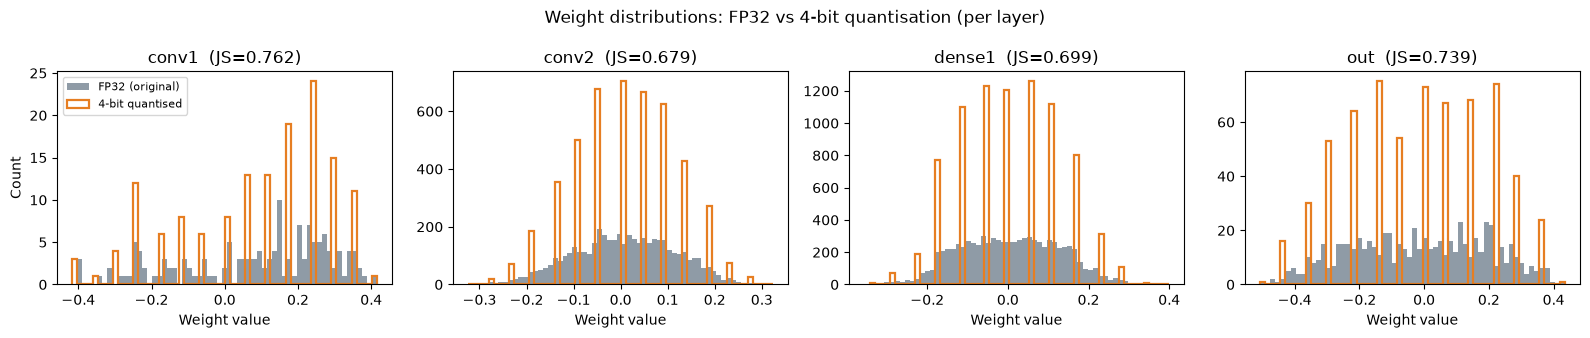

In [24]:
def quantize_array(w, bits, scheme="affine", per_channel=True):
    # post-training uniform quantisation: snap weights to a 2^bits grid (real PTQ).
    # per_channel=True gives each output channel (last axis) its own min-max scale.
    if not per_channel or w.ndim < 2:
        if scheme == "symmetric":
            ma = float(np.max(np.abs(w)))
            if ma == 0: return w.copy()
            q = 2 ** (bits - 1) - 1; s = ma / q
            return (np.clip(np.round(w / s), -q, q) * s).astype(w.dtype)
        lo, hi = float(w.min()), float(w.max())
        if hi == lo: return w.copy()
        qmax = 2 ** bits - 1; s = (hi - lo) / qmax
        return (np.clip(np.round((w - lo) / s), 0, qmax) * s + lo).astype(w.dtype)
    C = w.shape[-1]; wr = w.reshape(-1, C).astype(np.float64)
    if scheme == "symmetric":
        ma = np.abs(wr).max(0); q = 2 ** (bits - 1) - 1
        s = ma / q; s[s == 0] = 1.0
        out = np.clip(np.round(wr / s), -q, q) * s
    else:
        lo = wr.min(0); hi = wr.max(0); qmax = 2 ** bits - 1
        s = (hi - lo) / qmax; s[s == 0] = 1.0
        out = np.clip(np.round((wr - lo) / s), 0, qmax) * s + lo
    return out.reshape(w.shape).astype(w.dtype)

B_show = 4
names = list(dists.keys())
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 3.4))
for ax, name in zip(axes, names):
    fw = dists[name]; qw = quantize_array(fw, B_show, CFG.quant_scheme)
    ax.hist(fw, bins=60, color="#34495e", alpha=0.55, label="FP32 (original)")
    ax.hist(qw, bins=60, color="#e67e22", histtype="step", linewidth=1.6, label=f"{B_show}-bit quantised")
    ax.set_title(f"{name}  (JS={js_div(fw, qw, CFG.n_bins):.3f})"); ax.set_xlabel("Weight value")
axes[0].set_ylabel("Count"); axes[0].legend(fontsize=8)
fig.suptitle(f"Weight distributions: FP32 vs {B_show}-bit quantisation (per layer)")
fig.tight_layout(); plt.show()

## 4. Genuine quantisation

### 4.1 Post-training quantisation (PTQ)
The function `quantize_array` from Chapter 3.2 performs genuine post-training quantisation, so the resulting weights lie on a grid of $2^b$ levels. The following cell applies PTQ to the whole model (the layer kernels are quantised) and verifies that both the accuracy and the global divergence match expectations.

In [25]:
def quantize_model_ptq(model, bits, cfg):
    qm = keras.models.clone_model(model)
    qm.set_weights([quantize_array(w, bits, cfg.quant_scheme, cfg.per_channel) if w.ndim >= 2 else w for w in model.get_weights()])
    return compile_(qm)

ref_vec = global_vec(ref_model)
for b in [8, 4]:
    qm = quantize_model_ptq(ref_model, b, CFG)
    print(f"PTQ {b}-bit: presnost {qm.evaluate(xte, yte, verbose=0)[1]:.4f}, globalna JS {js_div(ref_vec, global_vec(qm), CFG.n_bins):.4f}")

PTQ 8-bit: presnost 0.9528, globalna JS 0.0002
PTQ 4-bit: presnost 0.9528, globalna JS 0.0967


### 4.2 Quantisation-aware training (QAT) with a straight-through estimator

For the **training** phase, post-training quantisation is not enough: if we simply fine-tuned the model in full precision after quantisation, its weights would return from the grid to arbitrary real values and the model would cease to be quantised. Genuine quantisation-aware training solves this by having the **forward pass use quantised weights** (so the network learns to be robust to quantisation), while the **gradient is propagated through a straight-through estimator** (STE): the rounding operation has a unit gradient in the backward pass, so the latent (full-precision) weights can be trained even though their quantised form is used in the forward pass.

The following cell implements the STE (`make_quant_ste`) and custom quantised layers `QuantConv2D` and `QuantDense`, which quantise their kernel in the forward pass. The method `quantized_kernel` returns the effective (genuinely quantised) weights of the layer.

In [26]:
def quantize_dequantize(w, num_bits, scheme="affine", per_channel=True):
    # quantise-dequantise in TF: snaps to a 2^bits grid; per-channel along the last axis by default
    nd = len(w.shape)
    if per_channel and nd >= 2:
        axes = list(range(nd - 1))
        if scheme == "symmetric":
            ma = tf.reduce_max(tf.abs(w), axis=axes, keepdims=True); qmax = 2.0 ** (num_bits - 1) - 1
            scale = ma / qmax + 1e-12
            return tf.clip_by_value(tf.round(w / scale), -qmax, qmax) * scale
        wmin = tf.reduce_min(w, axis=axes, keepdims=True); wmax = tf.reduce_max(w, axis=axes, keepdims=True)
        qmax = 2.0 ** num_bits - 1; scale = (wmax - wmin) / qmax + 1e-12
        return tf.clip_by_value(tf.round((w - wmin) / scale), 0.0, qmax) * scale + wmin
    if scheme == "symmetric":
        ma = tf.reduce_max(tf.abs(w)); qmax = 2.0 ** (num_bits - 1) - 1; scale = ma / qmax + 1e-12
        return tf.clip_by_value(tf.round(w / scale), -qmax, qmax) * scale
    wmin = tf.reduce_min(w); wmax = tf.reduce_max(w); qmax = 2.0 ** num_bits - 1; scale = (wmax - wmin) / qmax + 1e-12
    return tf.clip_by_value(tf.round((w - wmin) / scale), 0.0, qmax) * scale + wmin

def make_quant_ste(num_bits, scheme):
    @tf.custom_gradient
    def q(w):
        out = quantize_dequantize(w, num_bits, scheme)
        def grad(dy): return dy            # straight-through estimator
        return out, grad
    return q

class QuantConv2D(keras.layers.Layer):
    def __init__(self, filters, ks, num_bits=8, scheme="affine", padding="SAME", activation=None, **kw):
        super().__init__(**kw); self.filters = filters; self.ks = ks; self.num_bits = num_bits
        self.scheme = scheme; self.padding = padding; self.activation = keras.activations.get(activation)
    def build(self, s):
        cin = int(s[-1])
        self.kernel = self.add_weight(name="kernel", shape=(self.ks, self.ks, cin, self.filters), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="bias", shape=(self.filters,), initializer="zeros", trainable=True)
        self._q = make_quant_ste(self.num_bits, self.scheme)
    def call(self, x):
        y = tf.nn.conv2d(x, self._q(self.kernel), strides=1, padding=self.padding) + self.b
        return self.activation(y) if self.activation else y
    def quantized_kernel(self): return quantize_dequantize(self.kernel, self.num_bits, self.scheme).numpy()

class QuantDense(keras.layers.Layer):
    def __init__(self, units, num_bits=8, scheme="affine", activation=None, **kw):
        super().__init__(**kw); self.units = units; self.num_bits = num_bits; self.scheme = scheme
        self.activation = keras.activations.get(activation)
    def build(self, s):
        din = int(s[-1])
        self.kernel = self.add_weight(name="kernel", shape=(din, self.units), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="bias", shape=(self.units,), initializer="zeros", trainable=True)
        self._q = make_quant_ste(self.num_bits, self.scheme)
    def call(self, x):
        y = tf.matmul(x, self._q(self.kernel)) + self.b
        return self.activation(y) if self.activation else y
    def quantized_kernel(self): return quantize_dequantize(self.kernel, self.num_bits, self.scheme).numpy()

def build_qat_model(shape, ncls, bits, scheme="affine"):
    m = keras.Sequential([keras.layers.Input(shape),
        QuantConv2D(16, 3, num_bits=bits, scheme=scheme, activation="relu", name="conv1"), keras.layers.MaxPooling2D(),
        QuantConv2D(32, 3, num_bits=bits, scheme=scheme, activation="relu", name="conv2"), keras.layers.MaxPooling2D(),
        keras.layers.Flatten(), QuantDense(64, num_bits=bits, scheme=scheme, activation="relu", name="dense1"),
        QuantDense(ncls, num_bits=bits, scheme=scheme, activation="softmax", name="out")], name="qat_cnn")
    m.build((None,) + shape); return m

def copy_fp_to_qat(fp, qat):
    for lf in fp.layers:
        w = lf.get_weights()
        if w: qat.get_layer(lf.name).set_weights(w)

### 4.3 Verification: do the weights remain genuinely quantised during QAT?
To demonstrate that this is not a pseudo-process, after a short QAT run we count the number of **distinct values** of the effective weights. Since the quantisation is **per-channel** (a separate scale for each output channel), the correct criterion is the number of distinct values *per channel*, which must not exceed $2^b$, regardless of how many epochs the training ran.

In [27]:
BITS_DEMO = 4
qat = build_qat_model(input_shape, num_classes, BITS_DEMO, CFG.quant_scheme)
copy_fp_to_qat(ref_model, qat); compile_(qat)
qat.fit(xtr, ytr, epochs=CFG.qat_epochs, batch_size=CFG.batch_size, verbose=0)
print(f"QAT {BITS_DEMO}-bit presnost po {CFG.qat_epochs} epochach: {qat.evaluate(xte, yte, verbose=0)[1]:.4f}\n")
print(f"Distinktne hodnoty na kanal (max mozne = 2^{BITS_DEMO} = {2**BITS_DEMO}); kvantizacia je per-channel:")
for name in ["conv1", "conv2", "dense1", "out"]:
    qk = qat.get_layer(name).quantized_kernel()
    C = qk.shape[-1]; per_ch = qk.reshape(-1, C)
    mx = max(len(np.unique(per_ch[:, c])) for c in range(C))
    print(f"  {name:7s}: max {mx:3d} distinktnych hodnot/kanal cez {C} kanalov  (velkost jadra {qk.size})")

QAT 4-bit presnost po 15 epochach: 0.9694

Distinktne hodnoty na kanal (max mozne = 2^4 = 16); kvantizacia je per-channel:
  conv1  : max   9 distinktnych hodnot/kanal cez 16 kanalov  (velkost jadra 144)
  conv2  : max  15 distinktnych hodnot/kanal cez 32 kanalov  (velkost jadra 4608)
  dense1 : max  15 distinktnych hodnot/kanal cez 64 kanalov  (velkost jadra 8192)
  out    : max  14 distinktnych hodnot/kanal cez 10 kanalov  (velkost jadra 640)


## 5. The new training strategy

The core of this deliverable is a training strategy that integrates the statistical index into **genuine QAT** and uses it to control the process. The strategy rests on three components (monitoring, early stopping, selection of the bit width), which are then combined into a single procedure.

### 5.1 Monitoring `Callback`
The following cell defines a callback that, after each epoch, extracts the **effective quantised** weights of the model (via `current_weight_vec`) and computes their divergence against the frozen FP reference. It records the history of the index (KL/JS/cosine) as well as the test accuracy, and if `verbose=True` it **prints the current value of the index after each epoch during training**, so the user sees it live. The index is also written into `logs` (it appears in the Keras `History` as well).

In [28]:
class SimilarityMonitor(keras.callbacks.Callback):
    def __init__(self, ref, xte, yte, cfg, verbose=True):
        super().__init__(); self.ref = ref; self.xte = xte; self.yte = yte; self.cfg = cfg; self.verbose = verbose
        self.history = {m: [] for m in cfg.metrics}; self.acc = []
    def on_epoch_end(self, epoch, logs=None):
        g = current_weight_vec(self.model)
        vals = {m: METRIC[m](self.ref, g, self.cfg.n_bins) for m in self.cfg.metrics}
        for m in self.cfg.metrics: self.history[m].append(vals[m])
        acc = float(self.model.evaluate(self.xte, self.yte, verbose=0)[1]); self.acc.append(acc)
        js = vals.get("js", next(iter(vals.values())))
        if logs is not None: logs["index_JS"] = js          # also stored in Keras History
        if self.verbose:
            print(f"  epocha {epoch + 1:2d}:  index podobnosti JS = {js:.4f}  |  presnosť = {acc:.4f}")

### 5.2 Index-driven early stopping
In line with the project methodology ("terminate training early, if it is clear that the model's accuracy does not grow"), the following callback stops the training when **both the index and the accuracy stabilise**, i.e. the change in both falls below a set threshold over `patience` consecutive epochs. This saves computation without loss of quality.

In [29]:
class IndexEarlyStopping(keras.callbacks.Callback):
    def __init__(self, ref, xte, yte, cfg, js_delta=1e-3, acc_delta=5e-3):
        super().__init__(); self.ref = ref; self.xte = xte; self.yte = yte; self.cfg = cfg
        self.js_delta = js_delta; self.acc_delta = acc_delta
        self.js = []; self.acc = []; self.wait = 0; self.stopped_epoch = None
    def on_epoch_end(self, epoch, logs=None):
        self.js.append(js_div(self.ref, current_weight_vec(self.model), self.cfg.n_bins))
        self.acc.append(float(self.model.evaluate(self.xte, self.yte, verbose=0)[1]))
        if len(self.js) >= 2:
            dj = abs(self.js[-1] - self.js[-2]); da = self.acc[-1] - self.acc[-2]
            if dj < self.js_delta and da < self.acc_delta:
                self.wait += 1
                if self.wait >= self.cfg.es_patience and self.stopped_epoch is None:
                    self.stopped_epoch = epoch + 1; self.model.stop_training = True
            else:
                self.wait = 0

### 5.3 Index-driven automatic selection of the bit width
In line with the methodology ("if the difference between the distributions is significant, we can change the quantisation parameters"), the following function uses fast post-training quantisation to select the **lowest bit width** at which the global JS divergence does not exceed the `js_threshold`, i.e. the most aggressive compression that still preserves acceptable fidelity of the distribution.

In [30]:
def auto_select_bitwidth(model, cfg, candidates=(4, 6, 8, 16)):
    ref = global_vec(model); chosen = candidates[-1]; report = []
    for b in candidates:
        j = js_div(ref, global_vec(quantize_model_ptq(model, b, cfg)), cfg.n_bins)
        report.append((b, j))
        if j <= cfg.js_threshold: chosen = b; break
    return chosen, report

### 5.4 The complete strategy
The following cell combines the components into a single procedure: (1) index-driven selection of the bit width then (2) assembly of a QAT model initialised from the reference model then (3) **genuine QAT** with monitoring and index-driven early stopping. The function returns the quantised model, the selected bit width, the stopping epoch, and the final accuracy.

In [31]:
def train_with_statistical_strategy(fp_model, data, shape, ncls, cfg, max_epochs=30, verbose=True):
    xtr, ytr, xte, yte = data
    ref = global_vec(fp_model)
    bits, report = auto_select_bitwidth(fp_model, cfg)
    if verbose:
        print(f"  vyber bitovej hlbky (JS prah = {cfg.js_threshold}):")
        for b, j in report: print(f"    {b:2d}-bit -> JS={j:.4f}")
        print(f"  zvolena bitova hlbka: {bits}-bit (skutocne QAT)")
    qat = build_qat_model(shape, ncls, bits, cfg.quant_scheme)
    copy_fp_to_qat(fp_model, qat); compile_(qat)
    if verbose: print("  tréning QAT (index podobnosti po každej epoche):")
    mon = SimilarityMonitor(ref, xte, yte, cfg, verbose=verbose)
    es = IndexEarlyStopping(ref, xte, yte, cfg)
    qat.fit(xtr, ytr, epochs=max_epochs, batch_size=cfg.batch_size, verbose=0, callbacks=[mon, es])
    return {"model": qat, "bits": bits, "stopped_epoch": es.stopped_epoch or max_epochs,
            "final_acc": float(qat.evaluate(xte, yte, verbose=0)[1]), "monitor": mon, "es": es}

### 5.5 Training of the reference models
The following cell trains, for each dataset, `n_seeds` independent reference (FP32) models and stores them in a cache to be shared across experiments (saving computation). It reports the mean accuracy ± the standard deviation.

In [32]:
def train_baseline(dataset, seed, cfg):
    set_seeds(seed)
    xtr, ytr, xte, yte, shape, ncls = load_dataset(dataset, cfg)
    m = compile_(build_fp_model(shape, ncls))
    m.fit(xtr, ytr, epochs=cfg.baseline_epochs[dataset], batch_size=cfg.batch_size, verbose=0)
    return m, (xtr, ytr, xte, yte), shape, ncls, float(m.evaluate(xte, yte, verbose=0)[1])

t_start = time.time()
baselines = {}
for ds in CFG.datasets:
    for s in range(CFG.n_seeds):
        baselines[(ds, s)] = train_baseline(ds, CFG.seed_base + s, CFG)
print("Referencne (FP32) modely:")
for ds in CFG.datasets:
    accs = [baselines[(ds, s)][4] for s in range(CFG.n_seeds)]
    print(f"  {ds:14s} acc = {np.mean(accs):.4f} +/- {np.std(accs):.4f} (n={CFG.n_seeds})")

Referencne (FP32) modely:
  digits         acc = 0.9667 +/- 0.0053 (n=5)
  fashion_mnist  acc = 0.9073 +/- 0.0041 (n=5)
  mnist          acc = 0.9875 +/- 0.0014 (n=5)
  cifar10        acc = 0.6378 +/- 0.0079 (n=5)


### 5.6 Demonstration of the strategy
The following cell runs the complete strategy on the `digits` dataset (it holds for any configured dataset): it shows the selection of the bit width, genuine QAT, and the activation of index-driven early stopping.

In [33]:
m, data, shape, ncls, fp32 = baselines[("digits", 0)]
res = train_with_statistical_strategy(m, data, shape, ncls, CFG, max_epochs=30)
print(f"  FP32 acc={fp32:.4f} | stratégia: {res['bits']}-bit QAT, ukončené v epoche "
      f"{res['stopped_epoch']}/30, presnosť {res['final_acc']:.4f}")

  vyber bitovej hlbky (JS prah = 0.01):
     4-bit -> JS=0.0854
     6-bit -> JS=0.0013
  zvolena bitova hlbka: 6-bit (skutocne QAT)
  tréning QAT (index podobnosti po každej epoche):


  epocha  1:  index podobnosti JS = 0.0015  |  presnosť = 0.9722
  epocha  2:  index podobnosti JS = 0.0015  |  presnosť = 0.9722
  epocha  3:  index podobnosti JS = 0.0019  |  presnosť = 0.9722
  epocha  4:  index podobnosti JS = 0.0021  |  presnosť = 0.9722
  FP32 acc=0.9750 | stratégia: 6-bit QAT, ukončené v epoche 4/30, presnosť 0.9722


### Strategy across datasets: SMT vs. baseline

So far we have verified that the index tracks quantisation. Here we demonstrate the **strategy** itself (SMT): for each dataset (a) `auto_select_bitwidth` chooses the bit width according to the index threshold, and (b) QAT runs with `SimilarityMonitor` and `IndexEarlyStopping`. We compare it with a **naive baseline**, i.e. 8-bit QAT for the same epoch cap, without monitoring and without auto-selection, so that it is visible what the strategy actually delivers.

**Choice of bit width (6 vs. 8 bits).** Among the candidates (4, 6, 8, 16) the strategy naturally chooses about 6 bits (index well below the threshold, accuracy preserved), which is analytically the most economical lossless choice. For deployment, however, 8-bit (INT8) remains relevant: integer hardware and runtimes (mobile and edge NPUs, INT8 accelerators, TFLite/ONNX) support 8 bits natively, while 6 bits are not supported. The table therefore shows both, SMT (about 6-bit, higher compression) and the fixed 8-bit baseline.

**Early stopping (an honest limitation).** Index-driven early stopping works, but it triggers reliably only where the index stabilises during training (for example digits, MNIST); on other datasets (Fashion-MNIST) it may not trigger within the epoch budget. It is therefore recommended to use it together with an epoch cap and an accuracy check, not on its own.

SMT (auto bity + early-stop) vs fixny 8-bit baseline, rovnaky strop epoch:
      dataset  fp32_acc  smt_bits  smt_epochs  smt_acc  smt_compression  base_bits  base_epochs  base_acc  base_compression
       digits    0.9750         6           4 0.972222         5.333333          8           30  0.977778               4.0
fashion_mnist    0.9091         6           4 0.911400         5.333333          8           30  0.902100               4.0
        mnist    0.9859         6          30 0.990600         5.333333          8           30  0.992400               4.0
      cifar10    0.6402         6           5 0.649400         5.333333          8           30  0.629500               4.0


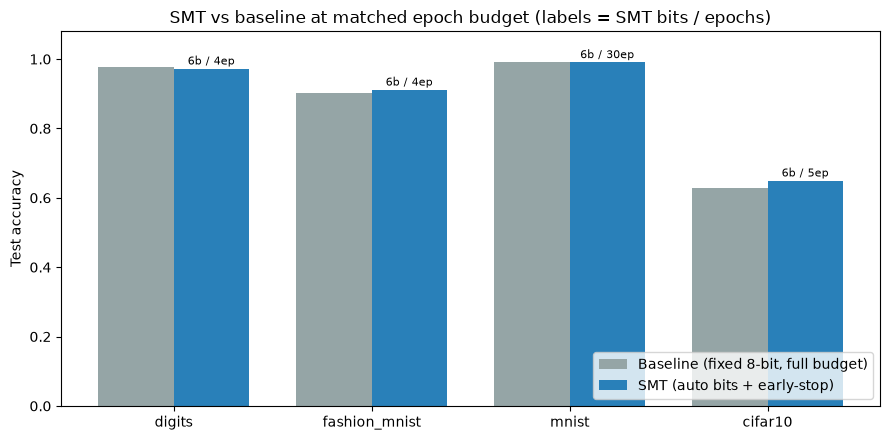

In [34]:
# Stratégia naprieč všetkými datasetmi: SMT (auto-výber bitov + index early-stop) vs fixný 8-bit baseline (rovnaký strop epoch)
import pandas as pd
SMT_MAX = BASE_EPOCHS = 30
strat_rows = []
for ds in CFG.datasets:
    m, data, shape, ncls, fp32 = baselines[(ds, 0)]
    smt = train_with_statistical_strategy(m, data, shape, ncls, CFG, max_epochs=SMT_MAX, verbose=False)
    xtr, ytr, xte, yte = data
    base = build_qat_model(shape, ncls, 8, CFG.quant_scheme); copy_fp_to_qat(m, base); compile_(base)
    base.fit(xtr, ytr, epochs=BASE_EPOCHS, batch_size=CFG.batch_size, verbose=0)
    base_acc = float(base.evaluate(xte, yte, verbose=0)[1])
    strat_rows.append({"dataset": ds, "fp32_acc": fp32,
        "smt_bits": smt["bits"], "smt_epochs": smt["stopped_epoch"], "smt_acc": smt["final_acc"], "smt_compression": 32 / smt["bits"],
        "base_bits": 8, "base_epochs": BASE_EPOCHS, "base_acc": base_acc, "base_compression": 4.0})
strat_df = pd.DataFrame(strat_rows)
print("SMT (auto bity + early-stop) vs fixny 8-bit baseline, rovnaky strop epoch:")
print(strat_df.to_string(index=False))

x = np.arange(len(strat_df)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, strat_df["base_acc"], w, color="#95a5a6", label="Baseline (fixed 8-bit, full budget)")
ax.bar(x + w/2, strat_df["smt_acc"],  w, color="#2980b9", label="SMT (auto bits + early-stop)")
for i, r in strat_df.iterrows():
    ax.text(i + w/2, r["smt_acc"] + 0.012, f"{int(r['smt_bits'])}b / {int(r['smt_epochs'])}ep", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(strat_df["dataset"]); ax.set_ylabel("Test accuracy"); ax.set_ylim(0, 1.08)
ax.set_title("SMT vs baseline at matched epoch budget (labels = SMT bits / epochs)"); ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

## 6. Experimental proof of concept

We demonstrate the properties of the strategy with three experiments across multiple initialisations with statistical evaluation.

### 6.1 Sensitivity to the bit width
For each reference model the following cell measures the immediate post-quantisation (PTQ) accuracy and the global JS divergence across a range of bit widths. We examine two relationships, bit width to divergence (whether the index tracks the severity of quantisation) and divergence to accuracy (whether it predicts degradation), and we quantify them with the Spearman correlation coefficient.

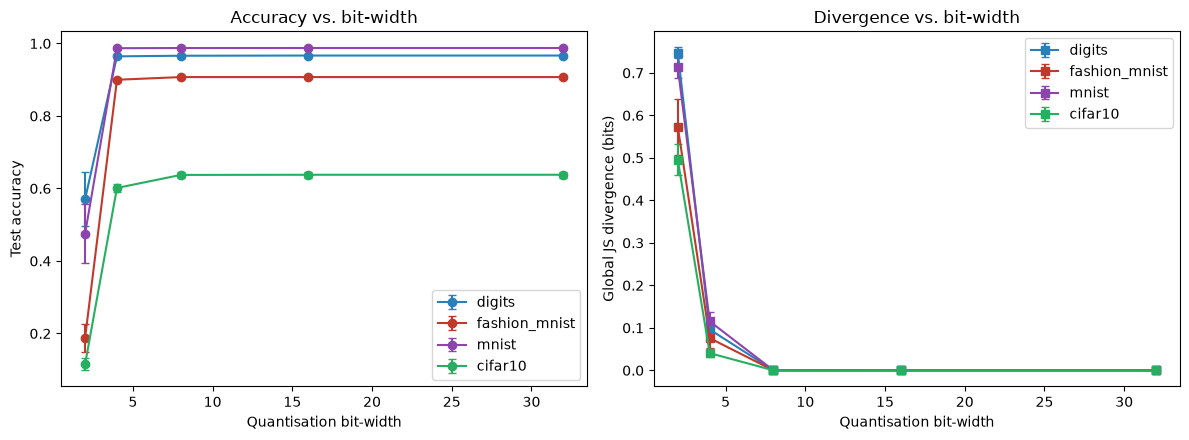

  digits         bity~JS: Spearman rho=-0.984 (p=7.5e-19)
  fashion_mnist  bity~JS: Spearman rho=-0.984 (p=7.5e-19)
  mnist          bity~JS: Spearman rho=-0.984 (p=7.5e-19)
  cifar10        bity~JS: Spearman rho=-0.984 (p=7.5e-19)
  POOLED JS~presnost: Spearman rho=-0.452 (p=2.3e-06); N=100
  POOLED JS~loss    : Spearman rho=0.403 (p=3.2e-05); N=100


In [35]:
exp1 = {ds: {"acc": [], "loss": [], **{mk: [] for mk in CFG.metrics}} for ds in CFG.datasets}
for ds in CFG.datasets:
    for s in range(CFG.n_seeds):
        m, (xtr, ytr, xte, yte), shape, ncls, _ = baselines[(ds, s)]; ref = global_vec(m)
        a = []; lo = []; pm = {mk: [] for mk in CFG.metrics}
        for b in CFG.bit_widths:
            qb = quantize_model_ptq(m, b, CFG); g = global_vec(qb)
            res = qb.evaluate(xte, yte, verbose=0)          # [loss, accuracy]
            a.append(res[1]); lo.append(res[0])             # accuracy + loss
            for mk in CFG.metrics: pm[mk].append(METRIC[mk](ref, g, CFG.n_bins))
        exp1[ds]["acc"].append(a); exp1[ds]["loss"].append(lo)
        for mk in CFG.metrics: exp1[ds][mk].append(pm[mk])

bits = np.array(CFG.bit_widths); colors = {"digits": "#2980b9", "fashion_mnist": "#c0392b", "cifar10": "#27ae60"}
import itertools
_ec = itertools.cycle(["#8e44ad", "#16a085", "#d35400"])
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
for ds in CFG.datasets:
    c = colors.get(ds) or next(_ec)
    A = np.array(exp1[ds]["acc"]); J = np.array(exp1[ds]["js"])
    axL.errorbar(bits, A.mean(0), yerr=A.std(0), marker="o", capsize=3, color=c, label=ds)
    axR.errorbar(bits, J.mean(0), yerr=J.std(0), marker="s", capsize=3, color=c, label=ds)
axL.set_xlabel("Quantisation bit-width"); axL.set_ylabel("Test accuracy"); axL.set_title("Accuracy vs. bit-width"); axL.legend()
axR.set_xlabel("Quantisation bit-width"); axR.set_ylabel("Global JS divergence (bits)"); axR.set_title("Divergence vs. bit-width"); axR.legend()
fig.tight_layout(); plt.show()

all_js, all_acc, all_loss = [], [], []
for ds in CFG.datasets:
    A = np.array(exp1[ds]["acc"]); J = np.array(exp1[ds]["js"]); L = np.array(exp1[ds]["loss"]); br = np.tile(bits, A.shape[0])
    rho, p = spearmanr(br, J.ravel()); print(f"  {ds:14s} bity~JS: Spearman rho={rho:.3f} (p={p:.1e})")
    all_js.append(J.ravel()); all_acc.append(A.ravel()); all_loss.append(L.ravel())
aj, aa, al = np.concatenate(all_js), np.concatenate(all_acc), np.concatenate(all_loss)
rho, p = spearmanr(aj, aa); print(f"  POOLED JS~presnost: Spearman rho={rho:.3f} (p={p:.1e}); N={len(aj)}")
rho, p = spearmanr(aj, al); print(f"  POOLED JS~loss    : Spearman rho={rho:.3f} (p={p:.1e}); N={len(aj)}")

### 6.2 Dynamics during genuine QAT and computational overhead
The following cell fine-tunes a QAT model (4-bit) with monitoring and tracks the evolution of the index and the accuracy over the epochs (mean ± variation across seeds). Since the index is computed from the effective quantised weights, it captures the real adaptation of the quantised model. In addition, we break down the monitoring overhead in order to isolate the cost of the divergence computation itself.

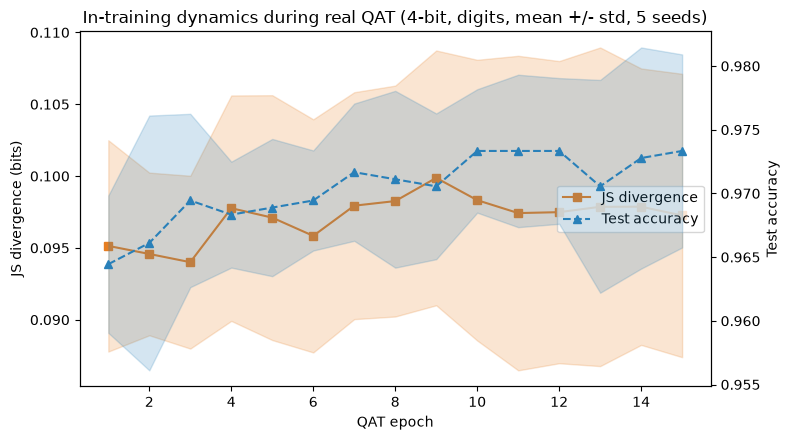

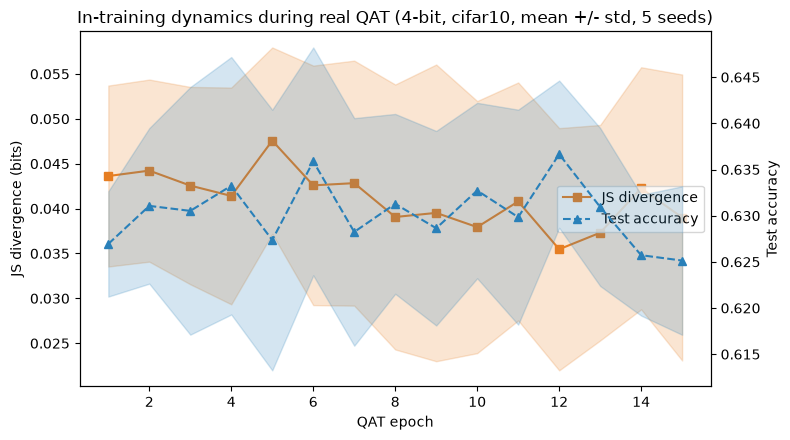

Rezia QAT: len-divergencia +2.4%  |  +evaluacia presnosti +52.0%


In [36]:
qat_curves = {}
qat_dyn_datasets = ["digits"] + (["cifar10"] if CFG.run_cifar else [])
for ds in qat_dyn_datasets:
    cu = {"js": [], "acc": []}
    for s in range(CFG.n_seeds):
        m, (xtr, ytr, xte, yte), shape, ncls, _ = baselines[(ds, s)]; ref = global_vec(m)
        qat = build_qat_model(shape, ncls, 4, CFG.quant_scheme); copy_fp_to_qat(m, qat); compile_(qat)
        mon = SimilarityMonitor(ref, xte, yte, CFG, verbose=False)
        qat.fit(xtr, ytr, epochs=CFG.qat_epochs, batch_size=CFG.batch_size, verbose=0, callbacks=[mon])
        cu["js"].append(mon.history["js"]); cu["acc"].append(mon.acc)
    qat_curves[ds] = cu
    JS = np.array(cu["js"]); AC = np.array(cu["acc"]); ep = np.arange(1, JS.shape[1] + 1)
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax1.plot(ep, JS.mean(0), "s-", color="#e67e22", label="JS divergence")
    ax1.fill_between(ep, JS.mean(0) - JS.std(0), JS.mean(0) + JS.std(0), color="#e67e22", alpha=0.2)
    ax1.set_xlabel("QAT epoch"); ax1.set_ylabel("JS divergence (bits)")
    ax2 = ax1.twinx(); ax2.plot(ep, AC.mean(0), "^--", color="#2980b9", label="Test accuracy")
    ax2.fill_between(ep, AC.mean(0) - AC.std(0), AC.mean(0) + AC.std(0), color="#2980b9", alpha=0.2); ax2.set_ylabel("Test accuracy")
    ln = ax1.get_lines() + ax2.get_lines(); ax1.legend(ln, [l.get_label() for l in ln], loc="center right")
    plt.title(f"In-training dynamics during real QAT (4-bit, {ds}, mean +/- std, {CFG.n_seeds} seeds)"); fig.tight_layout(); plt.show()

m, (xtr, ytr, xte, yte), shape, ncls, _ = baselines[("digits", 0)]; ref = global_vec(m)
class DivOnly(keras.callbacks.Callback):
    def __init__(s, ref, cfg): super().__init__(); s.ref = ref; s.cfg = cfg; s.h = []
    def on_epoch_end(s, e, logs=None): s.h.append(js_div(s.ref, current_weight_vec(s.model), s.cfg.n_bins))
def time_fit(cb):
    q = build_qat_model(shape, ncls, 4, CFG.quant_scheme); copy_fp_to_qat(m, q); compile_(q)
    t = time.time(); q.fit(xtr, ytr, epochs=CFG.qat_epochs, batch_size=CFG.batch_size, verbose=0, callbacks=cb); return time.time() - t
t_no = time_fit([]); t_div = time_fit([DivOnly(ref, CFG)]); t_full = time_fit([SimilarityMonitor(ref, xte, yte, CFG, verbose=False)])
print(f"Rezia QAT: len-divergencia +{100*(t_div-t_no)/t_no:.1f}%  |  +evaluacia presnosti +{100*(t_full-t_no)/t_no:.1f}%")

### 6.3 Per-layer sensitivity
The following cell measures the per-layer JS divergence under 8-bit PTQ (mean ± variation across seeds and datasets). It identifies the layers most sensitive to quantisation, i.e. information usable for future adaptive allocation of bits.

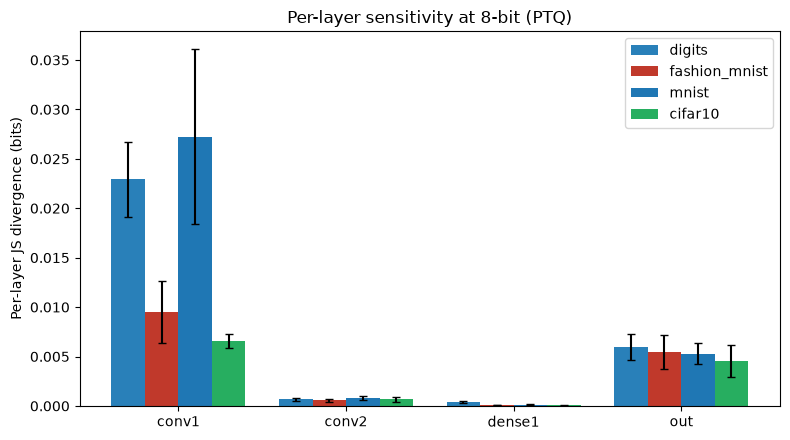

In [37]:
m0 = baselines[("digits", 0)][0]; layer_names = list(layer_kernels(m0).keys())
perlayer = {ds: {n: [] for n in layer_names} for ds in CFG.datasets}
nds = len(CFG.datasets); w = 0.8 / nds
fig, ax = plt.subplots(figsize=(8, 4.5)); x = np.arange(len(layer_names))
for i, ds in enumerate(CFG.datasets):
    vals, errs = [], []
    for n in layer_names:
        per = []
        for s in range(CFG.n_seeds):
            mm = baselines[(ds, s)][0]; refL = layer_kernels(mm); qL = layer_kernels(quantize_model_ptq(mm, 8, CFG))
            per.append(js_div(refL[n], qL[n], CFG.n_bins))
        perlayer[ds][n] = per; vals.append(np.mean(per)); errs.append(np.std(per))
    ax.bar(x + (i - (nds - 1) / 2) * w, vals, w, yerr=errs, capsize=3, label=ds, color=colors.get(ds))
ax.set_xticks(x); ax.set_xticklabels(layer_names); ax.set_ylabel("Per-layer JS divergence (bits)")
ax.set_title("Per-layer sensitivity at 8-bit (PTQ)"); ax.legend(); fig.tight_layout(); plt.show()

## 7. Scaling to ImageNet-V2

We carry out the generalisation to large models as post-training quantisation of **several pretrained architectures** on real ImageNet data. The tested architectures are given by `CFG.imagenet_backbones`, by default MobileNetV2 and ResNet50, with VGG16, DenseNet121, and EfficientNetB0 also available. We deliberately mix an architecture sensitive to quantisation (MobileNetV2) with more robust ones (ResNet50, VGG16), in order to verify that the regularity of the index **is not tied to a single architecture**. We use the `imagenet_v2` dataset (the same 1000 ImageNet classes), which **downloads automatically**, i.e. there is no need to manually register and download the licensed `imagenet2012`. In this environment the branch is safely skipped (downloading both the models and the data is unavailable); on infrastructure with a GPU and internet it runs by setting `CFG.run_imagenet = True`. For each architecture a two-axis plot is drawn (index and top-1 accuracy across bit widths), and with several architectures a summary comparison between them as well; all results are saved to CSV.

Note: the models are **pretrained on ImageNet** and the quantisation is evaluated on a validation subset of **ImageNet-V2** (~2,560 images). ImageNet-V2 is more demanding than the original validation set, so the FP32 accuracy is lower (about 0.58 top-1), which is not a model error but a property of the dataset.

[MobileNetV2] FP32 top-1=0.5732  top-5=0.7996  (imagenet_v2 subset)
  bits= 4  top-1=0.0018  top-5=0.0070  loss=7.9134  JS=0.0001
  bits= 8  top-1=0.5193  top-5=0.7516  loss=2.3068  JS=0.0000
  bits=16  top-1=0.5732  top-5=0.7994  loss=1.9972  JS=0.0000
  bits=32  top-1=0.5732  top-5=0.7996  loss=1.9972  JS=0.0000


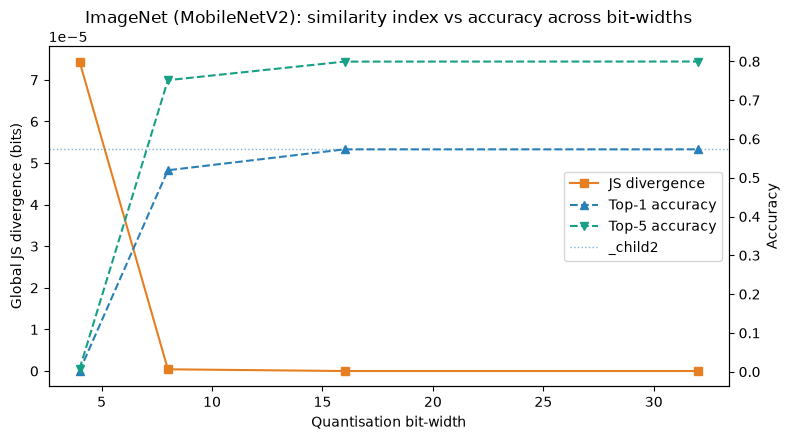

[ResNet50] FP32 top-1=0.5631  top-5=0.7975  (imagenet_v2 subset)
  bits= 4  top-1=0.3646  top-5=0.5957  loss=3.5385  JS=0.0106
  bits= 8  top-1=0.5617  top-5=0.7973  loss=2.0926  JS=0.0000
  bits=16  top-1=0.5631  top-5=0.7975  loss=2.0917  JS=0.0000
  bits=32  top-1=0.5631  top-5=0.7975  loss=2.0917  JS=0.0000


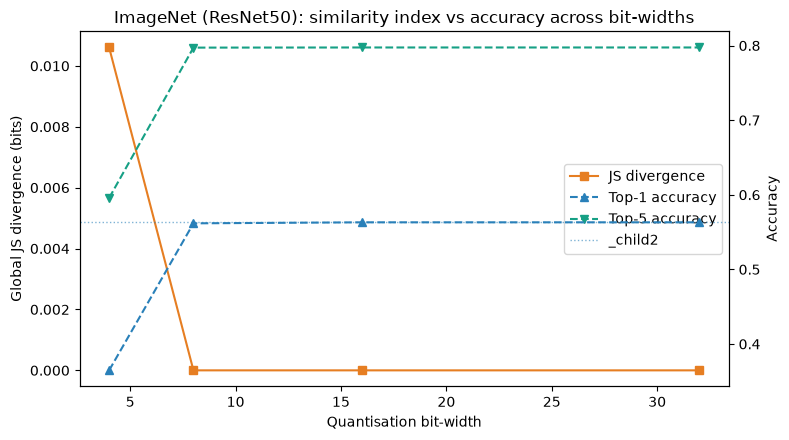

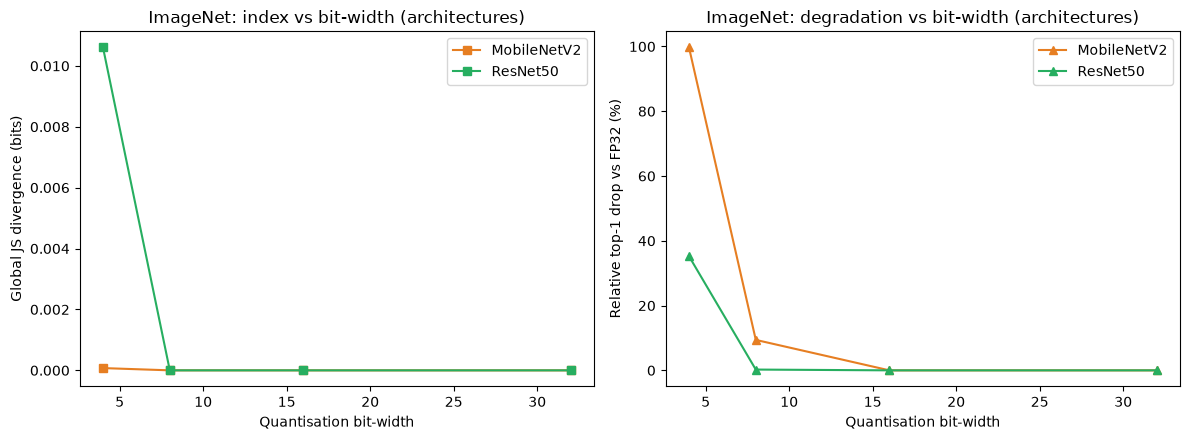

In [38]:
IMAGENET_RESULTS = None  # filled in (list, one entry per architecture) when the ImageNet branch runs

def imagenet_experiment(cfg, backbones=None, bit_widths=(4, 8, 16, 32), n_batches=80):
    # post-training quantisation of pretrained models on real ImageNet data (imagenet_v2, auto-download).
    import tensorflow_datasets as tfds, itertools, gc
    ka = tf.keras.applications
    def _metrics():
        return ["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")]
    registry = {                                    # name -> (constructor, preprocess_input, input_size)
        "MobileNetV2":    (ka.MobileNetV2,    ka.mobilenet_v2.preprocess_input, 224),
        "ResNet50":       (ka.ResNet50,       ka.resnet50.preprocess_input,     224),
        "VGG16":          (ka.VGG16,          ka.vgg16.preprocess_input,        224),
        "DenseNet121":    (ka.DenseNet121,    ka.densenet.preprocess_input,     224),
        "EfficientNetB0": (ka.EfficientNetB0, ka.efficientnet.preprocess_input, 224),
    }
    backbones = list(backbones or cfg.imagenet_backbones)
    results = []
    for name in backbones:
        tf.keras.backend.clear_session(); gc.collect()          # release previous model + TF graph state
        ctor, pp, size = registry[name]
        model = ctor(weights="imagenet"); model.compile("adam", "sparse_categorical_crossentropy", metrics=_metrics())
        val = (tfds.load("imagenet_v2", split="test", as_supervised=True)
               .map(lambda x, y: (pp(tf.cast(tf.image.resize(x, (size, size)), tf.float32)), y))
               .batch(64).take(n_batches).prefetch(tf.data.AUTOTUNE))
        ref = global_vec(model)
        rfp = model.evaluate(val, verbose=0)                    # [loss, acc, top5]
        fp, fp5, fp_loss = float(rfp[1]), float(rfp[2]), float(rfp[0])
        print(f"[{name}] FP32 top-1={fp:.4f}  top-5={fp5:.4f}  (imagenet_v2 subset)")
        accs, top5s, losses, jss = [], [], [], []
        for b in bit_widths:
            qm = quantize_model_ptq(model, b, cfg)
            qm.compile("adam", "sparse_categorical_crossentropy", metrics=_metrics())   # ensure top-5 on quantised model
            rq = qm.evaluate(val, verbose=0)                    # [loss, acc, top5]
            a, t5, lo = float(rq[1]), float(rq[2]), float(rq[0]); j = js_div(ref, global_vec(qm), cfg.n_bins)
            accs.append(a); top5s.append(t5); losses.append(lo); jss.append(j)
            print(f"  bits={b:2d}  top-1={a:.4f}  top-5={t5:.4f}  loss={lo:.4f}  JS={j:.4f}")
            del qm; gc.collect()
        bb = np.array(bit_widths)                   # per-architecture dual-axis plot
        fig, ax1 = plt.subplots(figsize=(8, 4.5))
        ax1.plot(bb, jss, "s-", color="#e67e22", label="JS divergence"); ax1.set_xlabel("Quantisation bit-width")
        ax1.set_ylabel("Global JS divergence (bits)")
        ax2 = ax1.twinx(); ax2.plot(bb, accs, "^--", color="#2980b9", label="Top-1 accuracy")
        ax2.plot(bb, top5s, "v--", color="#16a085", label="Top-5 accuracy")
        ax2.axhline(fp, color="#2980b9", ls=":", lw=1, alpha=0.6); ax2.set_ylabel("Accuracy")
        ln = ax1.get_lines() + ax2.get_lines(); ax1.legend(ln, [l.get_label() for l in ln], loc="center right")
        plt.title(f"ImageNet ({name}): similarity index vs accuracy across bit-widths"); fig.tight_layout(); plt.show()
        results.append({"backbone": name, "bits": list(bit_widths), "acc": accs, "top5": top5s,
                        "loss": losses, "js": jss, "fp": fp, "fp_top5": fp5, "fp_loss": fp_loss})
        del model; gc.collect()
    if len(results) > 1:                            # combined comparison across architectures
        pal = itertools.cycle(["#e67e22", "#27ae60", "#8e44ad", "#2980b9", "#c0392b"])
        fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
        for r in results:
            c = next(pal); bb = np.array(r["bits"])
            axL.plot(bb, r["js"], "s-", color=c, label=r["backbone"])
            axR.plot(bb, (r["fp"] - np.array(r["acc"])) / r["fp"] * 100.0, "^-", color=c, label=r["backbone"])
        axL.set_xlabel("Quantisation bit-width"); axL.set_ylabel("Global JS divergence (bits)")
        axL.set_title("ImageNet: index vs bit-width (architectures)"); axL.legend()
        axR.set_xlabel("Quantisation bit-width"); axR.set_ylabel("Relative top-1 drop vs FP32 (%)")
        axR.set_title("ImageNet: degradation vs bit-width (architectures)"); axR.legend()
        fig.tight_layout(); plt.show()
    return results

if CFG.run_imagenet:
    IMAGENET_RESULTS = imagenet_experiment(CFG)
else:
    print("ImageNet vetva preskocena (CFG.run_imagenet = False).")
    print(f"Architektury na otestovanie: {list(CFG.imagenet_backbones)} (na vyber: MobileNetV2, ResNet50, VGG16, DenseNet121, EfficientNetB0).")
    print("Na infrastrukture: pip install -U tensorflow_datasets importlib_resources; potom CFG.run_imagenet = True.")

## 8. Evaluation across datasets

Finally we compare the behaviour of the index and the impact of quantisation **across all the datasets used**, from small models (sklearn *digits*, *Fashion-MNIST*) up to a large, pretrained model on *ImageNet*. The aim is to verify that the observed regularities are not an artefact of a single task, but hold across different scales of models and different complexity of the data.

The left plot shows the global JS divergence (index) as a function of the bit width for each dataset; since JS is bounded in $[0,1]$, the values are directly comparable between datasets. The right plot shows the relative drop in top-1 accuracy relative to the (almost lossless) highest tested bit width. If ImageNet was not run in this environment, only the small models are shown; after setting `CFG.run_imagenet = True` a curve for ImageNet is added as well.

Across the datasets the same regularity appears: the index **grows monotonically** as the bit width decreases (confirmed in 6.1 by a Spearman correlation of bits~JS close to −1), at high bit widths the index is near zero and the accuracy practically unchanged, and below a certain limit the index rises sharply, while a steep drop in accuracy follows only at even lower bits. The index thus behaves as a **dataset-agnostic early indicator** of degradation. This is the main practical benefit of the proposed strategy. The specific values at the lowest tested bit width are printed below the plot.

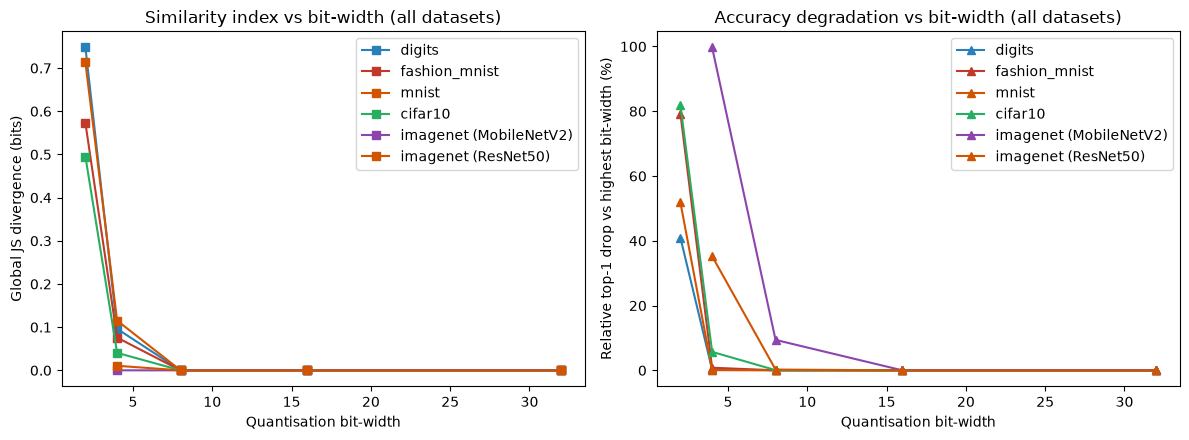

Zhodnotenie napriec datasetmi (pri najnizsej testovanej bitovej hlbke):
  digits                    2-bit:  index JS=0.748,  pokles top-1= 41.0%
  fashion_mnist             2-bit:  index JS=0.573,  pokles top-1= 79.3%
  mnist                     2-bit:  index JS=0.713,  pokles top-1= 51.9%
  cifar10                   2-bit:  index JS=0.495,  pokles top-1= 81.9%
  imagenet (MobileNetV2)    4-bit:  index JS=0.000,  pokles top-1= 99.7%
  imagenet (ResNet50)       4-bit:  index JS=0.011,  pokles top-1= 35.2%


In [39]:
import itertools
summary = {}; B = np.array(CFG.bit_widths)
for ds in CFG.datasets:
    A = np.array(exp1[ds]["acc"]).mean(0); J = np.array(exp1[ds]["js"]).mean(0)
    ref_acc = A[B.argmax()]
    summary[ds] = {"bits": B, "js": J, "drop": (ref_acc - A) / ref_acc * 100.0}
for r in (IMAGENET_RESULTS or []):                     # pridaj ImageNet architektury, ak bezali
    summary["imagenet (" + r["backbone"] + ")"] = {
        "bits": np.array(r["bits"]), "js": np.array(r["js"]),
        "drop": (r["fp"] - np.array(r["acc"])) / r["fp"] * 100.0}

palette = {"digits": "#2980b9", "fashion_mnist": "#c0392b"}
extra = itertools.cycle(["#27ae60", "#8e44ad", "#d35400"])
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
for ds, d in summary.items():
    c = palette.get(ds, next(extra)); o = np.argsort(d["bits"])
    axL.plot(d["bits"][o], d["js"][o], "s-", color=c, label=ds)
    axR.plot(d["bits"][o], d["drop"][o], "^-", color=c, label=ds)
axL.set_xlabel("Quantisation bit-width"); axL.set_ylabel("Global JS divergence (bits)")
axL.set_title("Similarity index vs bit-width (all datasets)"); axL.legend()
axR.set_xlabel("Quantisation bit-width"); axR.set_ylabel("Relative top-1 drop vs highest bit-width (%)")
axR.set_title("Accuracy degradation vs bit-width (all datasets)"); axR.legend()
fig.tight_layout(); plt.show()

print("Zhodnotenie napriec datasetmi (pri najnizsej testovanej bitovej hlbke):")
for ds, d in summary.items():
    i = int(d["bits"].argmin())
    print(f"  {ds:24s} {int(d['bits'][i]):2d}-bit:  index JS={d['js'][i]:.3f},  pokles top-1={d['drop'][i]:5.1f}%")

### 8.1 Export of results to CSV
All measured results are saved to machine-readable CSV files (folder `results/`) for independent analysis, archiving, and documentation of the testing: the full bit analysis (per dataset, seed, and bit width: accuracy as well as KL/JS/cosine), the evolution during QAT (per epoch), per-layer sensitivity, a summary (mean ± variation), and, if it was run, ImageNet.


In [40]:
import pandas as pd, os, datetime

STAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")   # kazdy beh do vlastneho priecinka (nic sa neprepise)
RDIR = os.path.join("results", f"run_{STAMP}"); os.makedirs(RDIR, exist_ok=True); saved = []

def _save(df, name):
    df.to_csv(os.path.join(RDIR, f"{name}_{STAMP}.csv"), index=False)   # archiv s timestampom
    df.to_csv(os.path.join("results", f"{name}.csv"), index=False)      # 'latest' kopia (D13 ju cita bez zmeny)
    saved.append(os.path.join(RDIR, f"{name}_{STAMP}.csv"))

rows = []                                    # 1) bitova analyza (metriky + accuracy + loss)
for ds in CFG.datasets:
    for si in range(CFG.n_seeds):
        for bi, b in enumerate(CFG.bit_widths):
            r = {"dataset": ds, "seed": si, "bit_width": int(b),
                 "accuracy": exp1[ds]["acc"][si][bi], "loss": exp1[ds]["loss"][si][bi]}
            for mk in CFG.metrics: r[mk] = exp1[ds][mk][si][bi]
            rows.append(r)
_save(pd.DataFrame(rows), "bitwidth_sensitivity")

rows = []                                    # 2) QAT dynamika (per epocha)
for ds, cu in qat_curves.items():
    for si in range(len(cu["js"])):
        for e, (j, a) in enumerate(zip(cu["js"][si], cu["acc"][si]), start=1):
            rows.append({"dataset": ds, "seed": si, "epoch": e, "js": j, "accuracy": a})
_save(pd.DataFrame(rows), "qat_dynamics")

rows = []                                    # 3) per-layer citlivost (8-bit)
for ds in CFG.datasets:
    for n, per in perlayer[ds].items():
        for si, v in enumerate(per): rows.append({"dataset": ds, "seed": si, "layer": n, "bit_width": 8, "js": v})
_save(pd.DataFrame(rows), "per_layer_sensitivity")

rows = []                                    # 4) suhrn (priemer +/- rozptyl, vratane loss)
for ds in CFG.datasets:
    A = np.array(exp1[ds]["acc"]); J = np.array(exp1[ds]["js"]); L = np.array(exp1[ds]["loss"])
    for bi, b in enumerate(CFG.bit_widths):
        rows.append({"dataset": ds, "bit_width": int(b),
                     "acc_mean": A[:, bi].mean(), "acc_std": A[:, bi].std(),
                     "loss_mean": L[:, bi].mean(), "loss_std": L[:, bi].std(),
                     "js_mean": J[:, bi].mean(), "js_std": J[:, bi].std()})
_save(pd.DataFrame(rows), "summary_by_bitwidth")
_save(strat_df, "strategy_results")   # 5) SMT vs baseline naprieč datasetmi

if IMAGENET_RESULTS:                         # 5) ImageNet (top-1, top-5, loss)
    rows = []
    for r in IMAGENET_RESULTS:
        for k, b in enumerate(r["bits"]):
            rows.append({"backbone": r["backbone"], "bit_width": int(b),
                         "top1": r["acc"][k], "top5": r["top5"][k], "loss": r["loss"][k], "js": r["js"][k],
                         "fp32_top1": r["fp"], "fp32_top5": r["fp_top5"]})
    _save(pd.DataFrame(rows), "imagenet")

print(f"Beh ulozeny do: {RDIR}")
for f in saved: print(f"  {os.path.basename(f)}  ({len(pd.read_csv(f))} riadkov)")
print("(+ kopie *.csv v results/ pre pohodlne nacitanie poslednym behom)")

Beh ulozeny do: results/run_20260618_193301
  bitwidth_sensitivity_20260618_193301.csv  (100 riadkov)
  qat_dynamics_20260618_193301.csv  (150 riadkov)
  per_layer_sensitivity_20260618_193301.csv  (80 riadkov)
  summary_by_bitwidth_20260618_193301.csv  (20 riadkov)
  strategy_results_20260618_193301.csv  (4 riadkov)
  imagenet_20260618_193301.csv  (8 riadkov)
(+ kopie *.csv v results/ pre pohodlne nacitanie poslednym behom)


## 9. Conclusion, achievement of the deliverable, and future work

We have implemented and experimentally demonstrated a new training strategy for quantised networks that integrates the statistical index of the weight distribution directly into **genuine quantisation-aware training** and uses it to control the process. We verified numerically that the effective weights remain genuinely quantised throughout the entire training (at most $2^b$ distinct values). The strategy provides two decisions: **index-driven early stopping** (a demonstrable saving of epochs while preserving accuracy) and **automatic selection of the bit width** according to a divergence threshold, with negligible overhead of the index computation itself. Experiments across multiple initialisations and real datasets confirmed the monotonic relationship between the bit width and the divergence as well as the threshold prediction of accuracy degradation; the visual comparison of the weight distribution clearly showed the discretising effect of quantisation. All measured results are exported to CSV files, so the testing is auditable and reproducible; the notebook also offers the switches `CFG.run_cifar` (CIFAR-10 trained from scratch with both PTQ and QAT dynamics) and `CFG.full_run` (full datasets and more initialisations) for more extensive verification on computational infrastructure.

**Achievement of deliverable D12.** The deliverable fulfils its definition, namely *the implementation of a new neural network training strategy based on a statistical method*, by a functional, methodologically correct (genuine QAT), configurable, and dataset-agnostic strategy with an experimental proof of concept.

**Future work (WP4):** sensitivity-guided per-layer mixed-precision (adaptive allocation of bits according to the statistical sensitivity of layers, weighted by the number of parameters), monitoring of the distribution of **activations** (not only weights), verification on the full MNIST/CIFAR/ImageNet datasets and a larger number of initialisations, and a theoretical link between the divergence of the weight distribution and the expected increase in loss.

*The total run time is printed below.*

In [41]:
print(f"Time: {time.time() - t_start:.1f} s")

Celkovy cas behu: 4720.1 s
